## Otorowiri

In [3]:
# import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import subprocess
import sys
import os
import pickle
import flopy
import geopandas as gpd
from shapely.geometry import LineString,Point,Polygon,MultiPolygon,MultiPoint,shape

%load_ext autoreload
%autoreload 2

import loopflopy
import loopflopy.utils as utils

modules = utils.list_modules(loopflopy)
#for module in modules: print(module)

os.getcwd()

loopflopy.__file__

'C:\\Users\\00105295\\Projects\\loopflopy\\src\\loopflopy\\__init__.py'

### 1. Setup Project

In [4]:
name = 'otorowiri'
workspace = '../modelfiles/'
results = '../results/'
figures = '../figures/'
triexe = '../exe/triangle.exe'
mfexe = '../exe/mf6.exe'

from loopflopy.project import Project
project = Project(name, workspace, results, figures, triexe, mfexe)
project.crs = 28350  # UTM zone 50S, EPSG:28350

### 2. Structural Model

#### 2.1 Bounding box

In [5]:
# A bounding box for structural model
x0, x1 = 320000, 400000
y0, y1 = 6670000, 6780000
z0, z1 = -1500, 400
bbox = [(x0, y0, z0), (x1, y1, z1)]

from loopflopy.spatial_routines import make_bbox_shp
crop_polygon = make_bbox_shp(x0, x1, y0, y1, crs=project.crs, fname = '../data/data_shp/structuralmodel.shp')

#### 2.2 Create the structural model object

In [6]:
# Create Structural Model object
geodata_fname = '../data/data_geology/bore_data_Otorowiri.xlsx'
data_sheetname = 'geodata_elevation'
strat_sheetname = 'strat'
from loopflopy.structuralmodel import StructuralModel
#spatial and bbox come from the spatial module, excel file and sheet names are user defined
structuralmodel = StructuralModel(bbox, geodata_fname, data_sheetname, strat_sheetname)

#### 2.3 Clip the DEM to the structural model

In [7]:
# Clip DEM to structuralmodel so its not such a big file to work with. 
# This only needs to be done once, so the line is commented out after running once. It takes about 5 minutes to run.
import process_dem
original_asc_path     = '../data/data_elevation/rasters_COP30/output_hh.asc'
crop_polygon_shp_path = '../data/data_shp/structuralmodel.shp'
output_tif_path       = '../data/data_dem/structuralmodel_dem.tif'
#process_dem.model_DEM(original_asc_path, crop_polygon_shp_path, output_tif_path) #only need to do once! About 5min

In [8]:
from loopflopy.dem import DEM
geotiff_fname = '../data/data_dem/structuralmodel_dem.tif'
dem_structural = DEM(geotiff_fname = geotiff_fname)

#### 2.4 Resample DEM to raster mesh

No special cells
EPSG:28350
EPSG:28350


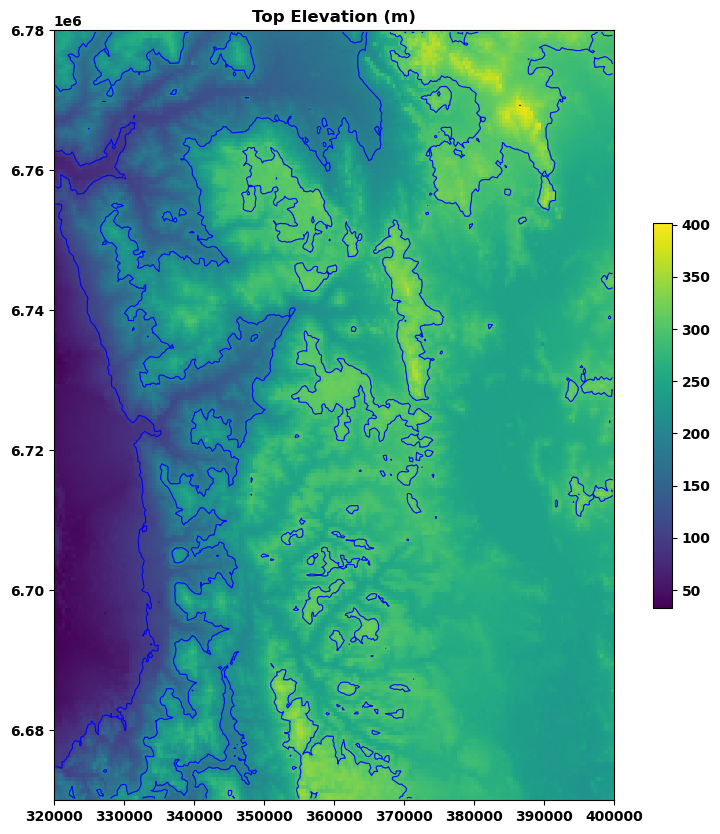

In [9]:
# Resample DEM to raster mesh to use for interpolation of structural model.
# This is so that the land surface is well represented in structural model instead of just using boreholes for interpolation.
from loopflopy.mesh_routines import create_structured_mesh
dem_grid = create_structured_mesh(bbox, ncol = 200, nrow = 200, crs = project.crs)

dem_structural.resample_topo(dem_grid, output_fname = '../modelfiles/structural_topo.pkl') # only need to run when mesh changes. Take 1-2 minutes
dem_structural.load_topo(fname = '../modelfiles/structural_topo.pkl')
dem_structural.plot_topo(dem_grid, levels = [0, 100, 200, 300, 400, 500, 600, 700])

structuralmodel.topo = dem_structural.topo
#structuralmodel.mesh = dem_grid

#### 2.5 Process structural model from spreadsheet

In [10]:
import process_structural

process_structural.geo_boundaries(project, structuralmodel, crop_polygon, simplify_tolerance =1000, node_spacing = 2000)
process_structural.prepare_strat_column(structuralmodel)
process_structural.add_geo_boundaries(structuralmodel)
process_structural.elevation_fill_all(structuralmodel) #this will fill all the boreholes with DEM elevations
process_structural.prepare_geodata(structuralmodel)
process_structural.create_structuralmodel(structuralmodel)


     sequence    unit    R    G    B   val  lithid Thickness  iconvert    hk  \
0      Ground  Ground  255  255  255     0      -1         -       NaN   NaN   
1  Yarragadee      Kp  172  186  242   124       0       NaN       1.0   8.0   
2  Yarragadee     Kpo  117  128  229   100       1       NaN       0.0   0.1   
3  Yarragadee      Jy  198  217  240 -1000       2       NaN       0.0  10.0   

     vk       ss    sy     Unnamed: 13  
0   NaN      NaN   NaN             NaN  
1   0.1  0.00010  0.10  hk should be 8  
2   0.1  0.00001  0.01             NaN  
3  10.0  0.00001  0.20             NaN  

Updated DataFrame with geo_boundaries written to new sheet: 'geo_boundaries' in file: ../data/data_geology/bore_data_Otorowiri.xlsx
Replaced elevation values for 167 points from DEM.
Updated elevations written to sheet: 'geodata_elevation' in ../data/data_geology/bore_data_Otorowiri.xlsx
167 valid elevation points retained for further processing.



Updated DataFrame written to new sheet: 'structuralmodel_data' in file: ../data/data_geology/bore_data_Otorowiri.xlsx
1.6.14


c:\Users\00105295\AppData\Local\anaconda3\envs\loopflopy\Lib\site-packages\LoopStructural\modelling\core\geological_model.py:646: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap, n_units)


#### 2.6 Plot cross-sections of the structural model

In [11]:
'''
z0 = -300 # just for plotting. Make sure within bbox of structural model
z1 = 300   # just for plotting. Make sure within bbox of structural model
nh, nz = 90, 90 # plotting resolution

transect_x = [360000, 375000]
structuralmodel.plot_xtransects2(transect_x, ny = 60, nz = 60, dz = [10,10], z0 = -400, z1 = 400) # Can add y0, y1 

# DONGARA LINE - 6750000
# ENEABBA LINE - 6700000
transect_y = [6700000, 6750000]
structuralmodel.plot_ytransects2(transect_y, nx = 60, nz = 60, dz = [10,10], x0 = 335000, x1 = 390000, z0 = -400, z1 = 400) #x0 = 335000, x1 = 352000, z0 = -200, z1 = 300
'''

'\nz0 = -300 # just for plotting. Make sure within bbox of structural model\nz1 = 300   # just for plotting. Make sure within bbox of structural model\nnh, nz = 90, 90 # plotting resolution\n\ntransect_x = [360000, 375000]\nstructuralmodel.plot_xtransects2(transect_x, ny = 60, nz = 60, dz = [10,10], z0 = -400, z1 = 400) # Can add y0, y1 \n\n# DONGARA LINE - 6750000\n# ENEABBA LINE - 6700000\ntransect_y = [6700000, 6750000]\nstructuralmodel.plot_ytransects2(transect_y, nx = 60, nz = 60, dz = [10,10], x0 = 335000, x1 = 390000, z0 = -400, z1 = 400) #x0 = 335000, x1 = 352000, z0 = -200, z1 = 300\n'

### 4. Model boundary

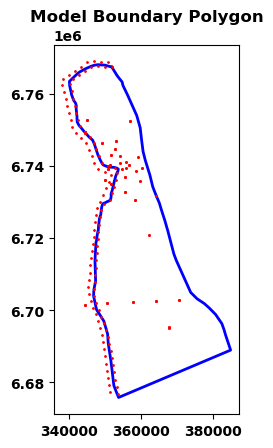

In [12]:
# Model boundary is actually complicated, so we had to add control points to make sure the 
# interpolation of the structural model is good around the boundary.
import process_boundary
shapefile_path = '../data/data_geology/Otorowiri_outcrop.xlsx'
model_boundary_poly = process_boundary.boundary_from_shapefile(shapefile_path, structuralmodel)

### 5. Spatial

#### 5.1 Set basics as spatial objects

POLYGON ((361337.20725018514 6735522.680110534, 361318.55532478204 6735525.34676506, 361300.2371096979 6735529.756794962, 361282.41518154956 6735535.871060632, 361265.24771234096 6735543.635297142, 361248.8870656651 6735552.98059585, 360589.151451948 6735972.229061367, 360574.4827576252 6735982.500582804, 359975.5522891828 6736443.188638042, 359972.66517840134 6736445.4518035585, 359627.74982986867 6736720.970266216, 359160.85397186875 6737035.591168093, 358646.0471174668 6737374.582637623, 358631.7419482652 6737384.935738192, 358618.4057506354 6737396.510296069, 358606.14248842536 6737409.21608047, 358595.04776129295 6737422.954042004, 358178.78923114884 6737987.677366506, 358168.802181669 6738002.582821196, 358160.19113841595 6738018.3233317, 357803.21527111484 6738746.661997532, 357802.45015107194 6738748.240553889, 357439.64677841234 6739505.1979318485, 356985.1587132632 6739946.094619135, 356649.4186185305 6740144.445396702, 355987.0582307656 6740394.382825348, 355969.0571409932 6

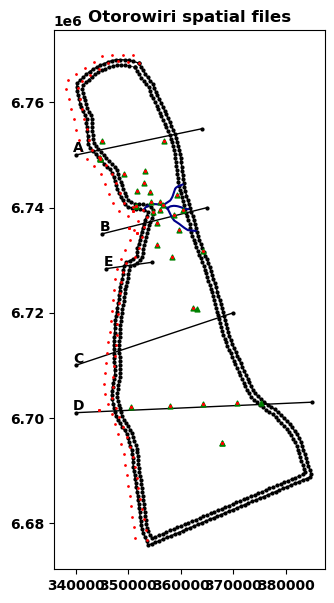

In [13]:
from loopflopy.spatial import Spatial
spatial = Spatial(epsg = project.crs)

import process_spatial
process_spatial.model_boundary(spatial, boundary_buff = 1000, simplify_tolerance = 0, node_spacing = 800)
process_spatial.geo_bores(spatial)
process_spatial.obs_bores(spatial)
process_spatial.pump_bores(spatial)
process_spatial.arrow(spatial, node_spacing = 300, buffer_distance = 200, threshold = 100)

# I'm not sure you will need these... (Kerry)
#process_spatial.GDEs(spatial)
#process_spatial.small_creek(spatial, buffer_distance = 200, node_spacing = 200, threshold = 100)
#process_spatial.sand_plain_creek(spatial, buffer_distance = 200, node_spacing = 200, threshold = 100)
#process_spatial.rivers(spatial, node_spacing = 200, buffer_distance = 200, threshold = 100)

spatial.xsection_names = ['A', 'B', 'C', 'D','E']
spatial.xsections = [
                     [(340000, 6750000),(364000, 6755000)], 
                     [(345000, 6735000),(365000, 6740000)],
                     [(340000, 6710000),(370000, 6720000)],
                     [(340000, 6701000),(385000, 6703000)],
                     [(345866, 6728401),(354545, 6729606)]
                     ]

extent = [[330000, 370000],[6720000, 6740000]]
#extent = [[330000, 370000],[6680000, 6770000]]
process_spatial.plot_spatial(spatial, structuralmodel,
                 labels = False, # Bore ids
                 obsbores = False, 
                 pumpbores = False, 
                 geobores = True, 
                 arrow = True, # Just arrowsmith
                 small_creek = False,
                 sand_plain = False,
                 fault_trace = False,
                 structuralmodel_data = True,
                 xsections = True,
                 #extent = extent # Just hash out to see the whole model
                 ) 

### TRANSECT

A


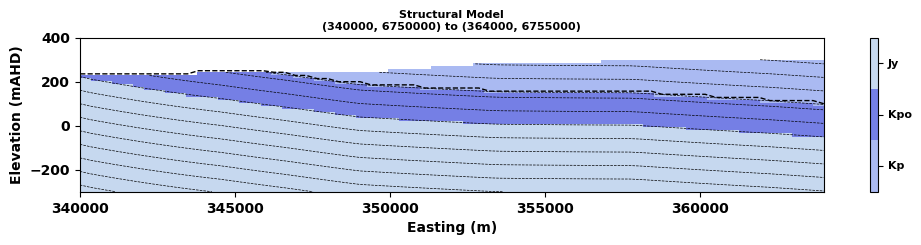

B


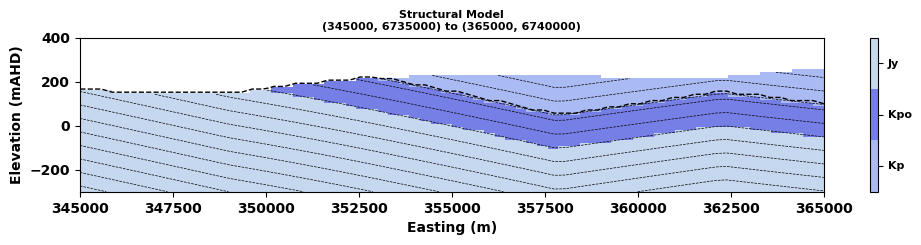

C


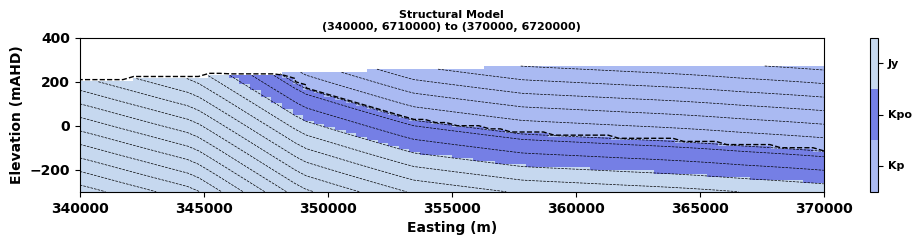

D


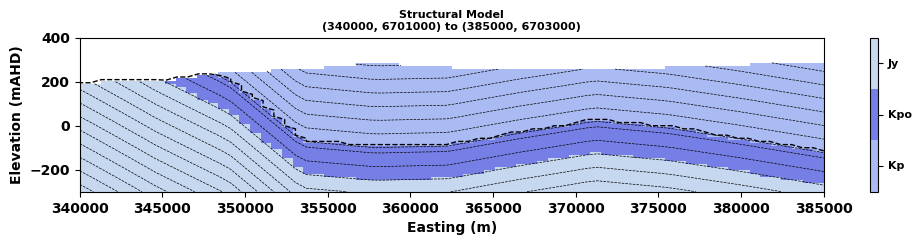

E


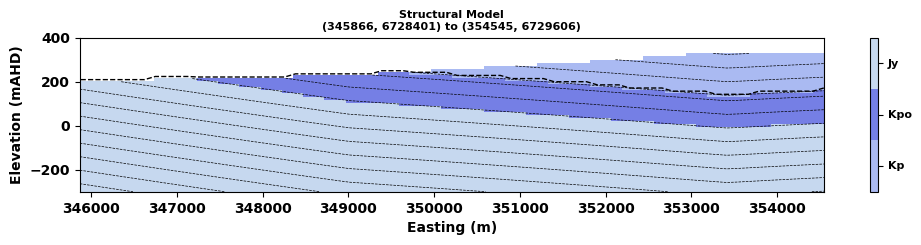

In [14]:
for name, section in zip(spatial.xsection_names, spatial.xsections):
    print(name)
    (x0, y0), (x1, y1) = section
    nh, nv = 70, 50
    dz = [10, 10, 10] # spacing of bedding layers
    z0, z1 = -300, 400
    structuralmodel.plot_transect(x0, x1, y0, y1, z0, z1, nh, nv, dz, figsize = (12,2))

#### Flow model transect start and end

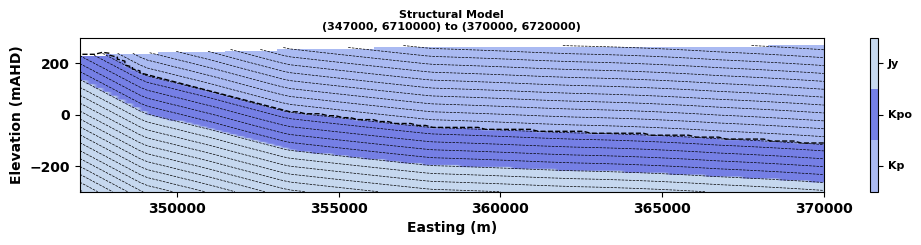

In [88]:
# Section C 
# Just becareful because if the section ends are too far past the boundary of the structural model, 
# it can cause errors because the interpolation of the structural model is not good outside the boundary.
section = spatial.xsections[2]
x0, y0, x1, y1 = 347000, section[0][1], section[1][0], section[1][1]

# Here we can change our transect location 
model_extent = [(x0, y0),(x1, y1)]
spatial.model_extent = model_extent
spatial.x0, spatial.x1 = model_extent[0][0], model_extent[1][0]
spatial.y0, spatial.y1 = model_extent[0][1], model_extent[1][1]

nh, nv = 100, 80
dz = [5, 5, 5] # spacing of bedding layers
z0, z1 = -300, 300
structuralmodel.plot_transect(x0, x1, y0, y1, z0, z1, nh, nv, dz, figsize = (12,2))

#### Transect mesh

In [16]:
# This makes a mesh (in plan) for the model and also 
# locates the cell numbers for special packages like CHD, GHB
special_cells = {'ghb': ['west',], 
                 'chd': ['east',]}

from loopflopy.mesh import Mesh
mesh = Mesh(plangrid = 'transect', special_cells = special_cells) # special cells to identify as arguements 

transect_length = ((x1 - x0)**2 + (y1 - y0)**2)**0.5
delc = 1000 # row width (doesnt matter as in transect) just made it 1km for plotting

# Irregularly spaced columns to refine around fault
segments = 5 #5
dx = [200, 200, 200, 200, 200] # Spacing of transect cells
#dx = [50, 75, 100, 150, 200] # Spacing of transect cells
L = x1 - x0
seg_notches = [x0, 
                x0 + 1*L/5, 
                x0 + 2*L/5, 
                x0 + 3*L/5,  
                x0 + 4*L/5, 
                x1]

print(seg_notches)
seg_x_length = [seg_notches[i+1] - seg_notches[i] for i in range(len(seg_notches)-1)]
ncol_per_seg = [int(seg_x_length[i]/dx[i]) for i in range(len(seg_x_length))]
delr = [seg_x_length[i]/ncol_per_seg[i] / ((x1-x0)/transect_length) for i in range(len(seg_x_length)) for _ in range(ncol_per_seg[i])]
delr = np.array(delr)

mesh.create_irregular_mesh_transect(project.crs, x0, x1, y0, y1, delc, delr)
#mesh.locate_special_cells(spatial) # KB Needs fixing this to work with transect mesh
print('number of cells in plan = ', mesh.ncpl)
print('Sum of the column thickness = ', np.sum(delr))
print('Transect length = ', transect_length)
print('rotation_angle  = ', mesh.angrot)

# Pickle results to get PRAMS recharge and head boundaries
fname = f'../modelfiles/inputs_for_prams_boundaries_dip.pkl'
pickle.dump([model_extent, mesh.xc, mesh.yc], open(fname, 'wb'))

[347000, 351600.0, 356200.0, 360800.0, 365400.0, 370000]

Transect length: 25079.872407968905
x0 =  347000  ,y0 =  6710000
x1 =  370000  ,y1 =  6720000
angrot  23.498565675952097
ncol =  115
number of cells in plan =  115
Sum of the column thickness =  25079.872407968913
Transect length =  25079.872407968905
rotation_angle  =  23.498565675952097


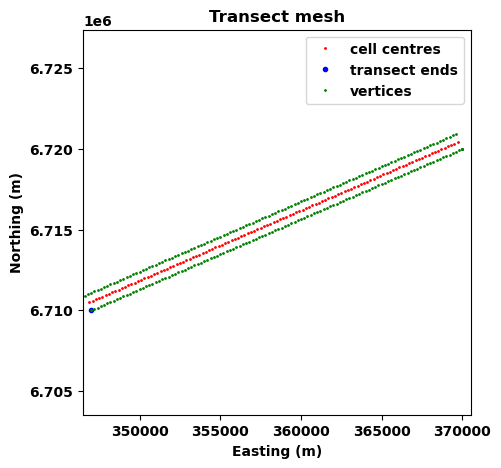

In [17]:
# This plots the cell centres (red), vertices (green) and transect ends (blue)
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(mesh.xcenters, mesh.ycenters, 'ro', ms= 1., label = 'cell centres')
ax.plot(spatial.x0, spatial.y0, 'bo', ms = 3., label = 'transect ends')
ax.plot(spatial.x1, spatial.y1, 'bo', ms = 1.)
for notch in range(segments + 1):
    ax.plot()
for ivert in mesh.vertices:
    i, x, y = ivert
    ax.plot(x, y, 'go', ms = 1.)
ax.plot(x, y, 'go', ms = 1., label = 'vertices')
ax.axis('equal')
ax.set_title('Transect mesh')
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_xlim([spatial.x0 - 500, spatial.x1 + 500])
#ax.set_ylim([spatial.y0 - 300, spatial.y1 + 50])
ax.legend()

#### DEM for Transect

None
EPSG:28350


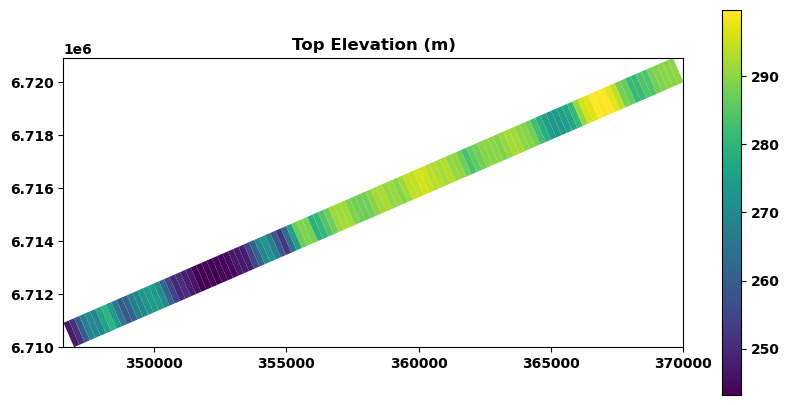

In [18]:
dem_geomodel = DEM(geotiff_fname = '../data/data_dem/structuralmodel_dem.tif')
#resample DEM to transect mesh
dem_geomodel.resample_topo(mesh, output_fname = '../modelfiles/geomodel_topo.pkl') 
dem_geomodel.load_topo(fname = '../modelfiles/geomodel_topo.pkl')
dem_geomodel.plot_topo(mesh, levels = [0, 100, 200, 300, 400, 500, 600, 700])

#### Geomodel

In [19]:
# Set up Geomodel (lithological block model of cells)
# If using voxel, the surface elevation can only be flat at the moment sorry.
# Needs work to make the "sky" cells disappear. I'm not sure how voxel works at the watetable really...

z0, z1 = -300, 400 # shouold really be 100, but voxel mesh does not accommodate empty cells yet

if z1 < np.max(dem_geomodel.topo):
    print('Warning: z1 is below the highest point of the DEM. Make sure z1 is above the highest point of the DEM to avoid errors.')

from loopflopy.geomodel import Geomodel
geomodel = Geomodel(scenario = 'Transect E', 
                    mesh = mesh, structuralmodel = structuralmodel, 
                    vertgrid = 'con2', 
                    z0 = z0, 
                    z1 = z1, 
                    transect = True, 
                    #nlay = 50 # Number of layers you want to model (VOX only)
                    )

surface = dem_geomodel.topo
#surface = np.ones((mesh.nrow, mesh.ncol))*100
geomodel.evaluate_structuralmodel(res = 2)

geomodel.create_model_layers(surface, 
                                max_thick = [50], 
                                nlg = 1, # Number of geological layers you want to model
                                nls = 2, # Number of sublayers (flow layers within geo layer)
                                pinchouts = False, # If false, then enforces continous layer
                            )
# Save geomodel for later use
import cloudpickle
fname = f'../modelfiles/geomodel.pkl'
with open(fname, 'wb') as f:
    cloudpickle.dump(geomodel, f)
print(f'Geomodel saved to {fname}')

Creating Geomodel for  Transect E  ...

0. Creating xyz array... 
***  -300 400 2
   Time taken Block 0 (creating xyz array) =  0.015629

1. Evaluating structural model... 
   len(xyz) =  40250
   Time taken Block 1 (Evaluate model) =  0.165023

2. Creating geo model layers...
   dz calculated from z0, z1 and nlay =  2.0
   nlay =  350
   ncpl =  115
   nlg number of geo layers =  3
   botm_geo_shape (3, 115)
   Note: Geomodel bottom = geological layer bottom (not flat bottom)
   Checked geological layer 0: Kp for pinchouts.
     Number of cells with negative thickness that have been converted=  0
     New min thickness =  11.123977661132812 New max thickness =  402.09234619140625 

   idomain_geo unique values and counts:  (array([1.]), array([115]))
   Time taken Block 2 (Create geological model layers) 0.0

3. Creating flow model layers...
   Time taken Block 3 create flow model layers =  0.015409

4. Calculating cellids and gradients...
   Time taken Block 4 gradients=  0.030073
Ge

In [20]:
# Unpickle geomodel to check it loads correctly
from loopflopy.geomodel import Geomodel
fname = f'../modelfiles/geomodel.pkl'
with open(fname, 'rb') as f:
	geomodel = cloudpickle.load(f)

# GEOMODEL DETAILS:
print('Transect extent in x direction: ', spatial.x0, ' to ', spatial.x1)
print('Transect extent in z direction: ', geomodel.z0, ' to ', geomodel.z1)
print('Number of columns = ', geomodel.ncpl, ', Number of layers = ', geomodel.nlay)
print('Number of cells total in transect = ', geomodel.ncell_disv)
print('First column width (delr) = ', mesh.delr[0])
print('Last column width (delr) = ', mesh.delr[-1])
print('Resolution in the vertical = ', geomodel.dz)

Transect extent in x direction:  347000  to  370000
Transect extent in z direction:  -300  to  400
Number of columns =  115 , Number of layers =  9
Number of cells total in transect =  1035
First column width (delr) =  218.08584702581655
Last column width (delr) =  218.08584702581655
Resolution in the vertical =  2.0


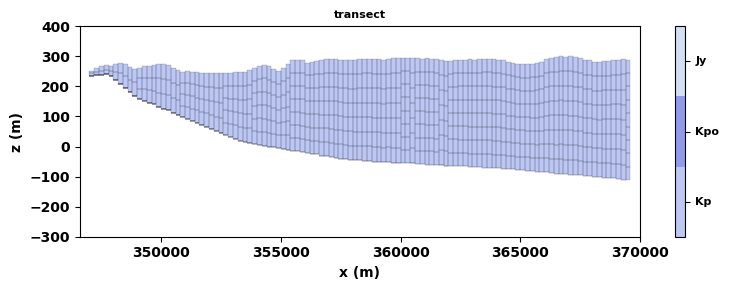

In [21]:
# you can add limits for plotting including x0, x1, z0, z1
geomodel.geomodel_transect_lith(title = 'transect', 
                                xlim = [mesh.xc[0]-300, mesh.xc[-1]+300], # For plotting
                                #zlim = [100, 300], # For plotting
                                figsize = (8,3)) 

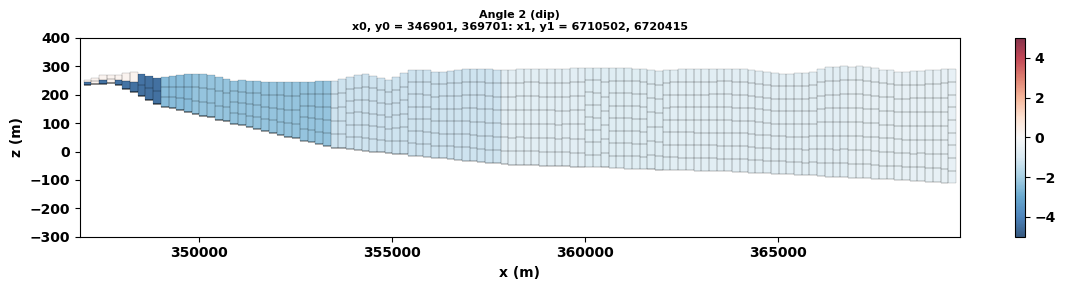

In [22]:
title = f"Angle 2 (dip)"
array = geomodel.ang2
geomodel.geomodel_transect_array(array, title, 
                                 grid = True,
                                 cmap = 'RdBu_r',
                                 x0=mesh.xc[0], x1=mesh.xc[-1], 
                                 y0=mesh.yc[0], y1=mesh.yc[-1],
                                 #xlim = [mesh.xc[0], 352500], # For plotting
                                 #zlim = [210, 240], # For plotting
                                 vmin = -5, #array.min(), 
                                 vmax = 5, #array.max(), 
                                 figsize = (12,3))

#### Fill properties

In [23]:
# FILL CELL PROPERTIES
import pandas as pd

print("Reading hydraulic properties from... ", structuralmodel.geodata_fname)
props = pd.read_excel(structuralmodel.geodata_fname, sheet_name = 'strat')
props = props.drop(index=[0]).reset_index()#inplace=True) # drop first row as it is ground

geomodel.hk_perlay = props.hk.tolist()
geomodel.vk_perlay = props.vk.tolist()
geomodel.ss_perlay = props.ss.tolist()
geomodel.sy_perlay = props.sy.tolist()
geomodel.iconvert_perlay = props.iconvert.tolist()

Reading hydraulic properties from...  ../data/data_geology/bore_data_Otorowiri.xlsx


In [24]:
geomodel.iconvert_perlay = [0, 0, 0] # This is just for testing. Set to 0 for all layers so that the model is unconfined.
geomodel.hk_perlay = [8., 0.00001, 0.00001] # Spreadsheet = [8.0, 0.1, 10.0]
geomodel.vk_perlay = [0.001, 0.00001, 0.00001] # Spreadsheet = [0.1, 0.1, 10.0]
geomodel.fill_cell_properties(mesh)


5. Filling cell properties...
   ang1 shape  (9, 115)
   angle1 shape  (715,)
   Time taken Block 5 Fill cell properties =  0.001001


#### Boundaries

In [25]:
print(geomodel.k11.min(), geomodel.k11.max())
print(geomodel.logk11.min(), geomodel.logk11.max())

8.0 8.0
0.9030899869919435 0.9030899869919435


In [26]:
class InitialCondition:
    def __init__(self):

        self.strt = 150. # start with a watertable everywhere. Doens't really matter if steady-state!

In [27]:
west_cell = mesh.vgrid.intersect(mesh.xc[0], mesh.yc[0])
print(f'Cell number at {mesh.xc[0], mesh.yc[0]} is = {west_cell}')

east_cell = mesh.vgrid.intersect(mesh.xc[-1], mesh.yc[-1])
print(f'Cell number at {mesh.xc[-1], mesh.yc[-1]} is = {east_cell}')

Cell number at (np.float64(346900.63694429275), np.float64(6710502.013288996)) is = 0
Cell number at (np.float64(369700.6369442928), np.float64(6720415.056767258)) is = 114


In [28]:
west_cells=[]
for cell in range(mesh.ncpl):
    x, y = mesh.xc[cell], mesh.yc[cell]
    if x < 350000:
        west_cells.append(cell)
print('Number of west cells = ', len(west_cells))

Number of west cells =  16


In [29]:
class Boundaries:
    def __init__(self, disu = True):

        self.data_label = "DataBaseClass"
        self.disu = disu

    def rch(self, geomodel, mesh, rate):

        # Assume constant and homogeneous recharge for now
        recharge = np.ones(mesh.ncpl) * rate # m/day
        rec = []
        for icpl in range(mesh.ncpl):
            lay = 0
            cell_disv = icpl + lay*mesh.ncpl
            cell_disu = geomodel.cellid_disu.flatten()[cell_disv]
            rch = recharge[icpl]
            if self.disu: # DISU model
                rec.append((cell_disu, rch))
            else: # DISV model
                rec.append(((0, icpl), rch)) 

        self.rch_rec = {}      
        self.rch_rec[0] = rec 

    def evt(self, geomodel, mesh, max_evt_rate, ext_depth):
        # Assume constant and homogeneous EVT for now
        evt = []
        for icpl in range(mesh.ncpl):
            lay = 0
            cell_disv = icpl + lay*mesh.ncpl
            cell_disu = geomodel.cellid_disu.flatten()[cell_disv]
            surface = geomodel.top[icpl]
            
            if cell_disu != -1: # if cell is not pinched out...
                if self.disu: # DISU model
                    evt.append((cell_disu, surface, max_evt_rate, ext_depth))
                else: # DISV model
                    evt.append(((0, icpl), surface, max_evt_rate, ext_depth)) 

        self.evt_rec = {}      
        self.evt_rec[0] = evt

    def chd(self, geomodel, mesh, east_cell, head = 300):
        
        self.chd_rec = []

        # EAST BOUNDARY
        icpl = east_cell
        #head = geomodel.top[east_cell] - 0.5
        for lay in range(geomodel.nlay): 
            if head > geomodel.botm[lay, icpl]: # if head is not below cell bottom...
                cell_disv = icpl + lay*mesh.ncpl
                cell_disu = geomodel.cellid_disu.flatten()[cell_disv]
                if cell_disu != -1: # if cell is not pinched out...
                    if self.disu: # DISU model
                        self.chd_rec.append([cell_disu, head]) # node, stage, conductance
                    else: # DISV model
                        self.chd_rec.append([(lay, icpl), head]) # node, stage, conductance

    # DRAIN - WESTERN MOST CELL
    def drn(self, geomodel, mesh, west_cells, conductance, drain_depth):
        
        self.drn_rec = []

        # WEST BOUNDARY
        lay = 0 # Top layer only for drain
        
        for icpl in west_cells:
            land_surface = geomodel.top[icpl] # ground elevation at the cell
            drain_elevation = land_surface - drain_depth # bottom of drain elevation
            cell_disv = icpl + lay*mesh.ncpl
            cell_disu = geomodel.cellid_disu.flatten()[cell_disv]
            if cell_disu != -1: # if cell is not pinched out...
                if self.disu: # DISU model
                    self.drn_rec.append([cell_disu, drain_elevation, conductance])  
                else: # DISV model
                    self.drn_rec.append([(lay, icpl), drain_elevation, conductance]) 

    # DRAIN - ALL LANDSURFACE
    def drn2(self, geomodel, mesh, conductance):
        
        self.drn2_rec = []

        # All top cells
        for icpl in range(mesh.ncpl):
            land_surface = geomodel.top[icpl] # ground elevation at the cell
            drain_depth = 0.
            drain_elevation = land_surface - drain_depth # bottom of drain elevation
            for lay in range(1): # Just top layer
                cell_disv = icpl + lay*mesh.ncpl
                cell_disu = geomodel.cellid_disu.flatten()[cell_disv]
                if cell_disu != -1: # if cell is not pinched out...
                    if self.disu: # DISU model
                        self.drn2_rec.append([cell_disu, drain_elevation, conductance])  
                    else: # DISV model
                        self.drn2_rec.append([(lay, icpl), drain_elevation, conductance]) 

In [30]:
initialcondition = InitialCondition()

boundaries = Boundaries()
boundaries.rch(geomodel, mesh, rate = 0.0001) # Recharge rate in m/day
boundaries.evt(geomodel, mesh, max_evt_rate = 0.003, ext_depth = 5)
boundaries.chd(geomodel, mesh, east_cell, head = 300)
boundaries.drn(geomodel, mesh, west_cells, conductance = 10000, drain_depth = 1) # Western cell
boundaries.drn2(geomodel, mesh, conductance = 100000) # All cells

#### Observations

In [31]:
def make_obs_df(mesh, geomodel, nobs_x = 10, nobs_z = 3):
    """
    Create a DataFrame of observation points based on the mesh and geomodel.
    Observation points are sampled from the cell centres in the x-y plane and
    vertically distributed between z0 and z1 of the geomodel.
    """

    # Make fake observation points by sampling cell centres (saves interpolating later!)
    a = np.linspace(0, len(mesh.xcyc)-1, nobs_x+2, dtype=int)[1:-1]
    x = [mesh.xcyc[i][0] for i in a]  # Extract x coordinates directly  
    y = [mesh.xcyc[i][1] for i in a]  # Extract y coordinates directly
    print(len(x), len(y))
    #for i in x: print(i)
    #for i in y: print(i)

    # Making observation points in vertical direction
    z = np.linspace(geomodel.z1, geomodel.z0, nobs_z+2)[1:-1] # Don't include edges! 

    obs_points = []
    for i in range(len(x)):
        for j in range(len(z)):
            obs_points.append([x[i], y[i], z[j]]) 
    print(len(obs_points)) # Should be nobs_x * nobs_z
    print(obs_points)

    X,Y,Z = list(zip(*obs_points))

    # Create DataFrame
    df = pd.DataFrame({
        'id': [str('obs_%i' %i) for i in np.arange(len(X))],
        'x': X,
        'y': Y,
        'z': Z,
    })
    return df

In [32]:
def make_obs_gdf(df, geomodel, mesh, spatial):

    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.x, df.y), crs=spatial.epsg)

    gdf['icpl'] = gdf.apply(lambda row: mesh.vgrid.intersect(row.x,row.y), axis=1)
    gdf['ground'] = gdf.apply(lambda row: geomodel.top[row.icpl], axis=1)
    gdf['model_bottom'] = gdf.apply(lambda row: geomodel.botm[-1, row.icpl], axis=1)
    gdf['z-bot'] = gdf.apply(lambda row: row['z'] - row['model_bottom'], axis=1)

    for idx, row in gdf.iterrows():
        result = row['z'] - row['model_bottom']
        if result < 0:
            print(f"Bore {row['id']} has an elevation below model bottom by: {result} m, removing from obs list")

    gdf = gdf[gdf['z-bot'] > 0] # filters out observations that are below the model bottom
    gdf['cell_disv'] = gdf.apply(lambda row: utils.xyz_to_disvcell(geomodel, row.x, row.y, row.z), axis=1)
    gdf['cell_disu'] = gdf.apply(lambda row: utils.disvcell_to_disucell(geomodel, row['cell_disv']), axis=1)  
    gdf['(lay,icpl)'] = gdf.apply(lambda row: utils.disvcell_to_layicpl(geomodel, row['cell_disv']), axis = 1)
    gdf['lay']        = gdf.apply(lambda row: row['(lay,icpl)'][0], axis = 1)
    gdf['icpl']       = gdf.apply(lambda row: row['(lay,icpl)'][1], axis = 1)
    gdf['obscell_xy'] = gdf['icpl'].apply(lambda icpl: (mesh.xcyc[icpl][0], mesh.xcyc[icpl][1]))
    gdf['obscell_z']  = gdf.apply(lambda row: geomodel.zc[row['lay'], row['icpl']], axis=1)
    gdf['obs_zpillar']  = gdf.apply(lambda row: geomodel.zc[:, row['icpl']], axis=1)
    if geomodel.vertgrid != 'vox':
        gdf['geolay']       = gdf.apply(lambda row: math.floor(row['lay']/geomodel.nls), axis = 1) # model layer to geolayer

    # Make sure no pinched out observations
    if -1 in gdf['cell_disu'].values:
        print('Warning: some observations are pinched out. Check the model and data.')
        print('Number of pinched out observations removed: ', len(gdf[gdf['cell_disu'] == -1]))
        gdf = gdf[gdf['cell_disu'] != -1] # delete pilot points where layer is pinched out

    return gdf

In [33]:
# Make 30 observation points - 10 spaced equally across, 3 down
# Then add discretisation details (cell ids) to obs points
import math
df = make_obs_df(mesh, geomodel, nobs_x = 10, nobs_z = 3)
df_boredetails = make_obs_gdf(df, geomodel, mesh, spatial)

10 10
30
[[np.float64(348900.63694429275), np.float64(6711371.578506388), np.float64(225.0)], [np.float64(348900.63694429275), np.float64(6711371.578506388), np.float64(50.0)], [np.float64(348900.63694429275), np.float64(6711371.578506388), np.float64(-125.0)], [np.float64(350900.63694429275), np.float64(6712241.143723779), np.float64(225.0)], [np.float64(350900.63694429275), np.float64(6712241.143723779), np.float64(50.0)], [np.float64(350900.63694429275), np.float64(6712241.143723779), np.float64(-125.0)], [np.float64(353100.63694429275), np.float64(6713197.665462909), np.float64(225.0)], [np.float64(353100.63694429275), np.float64(6713197.665462909), np.float64(50.0)], [np.float64(353100.63694429275), np.float64(6713197.665462909), np.float64(-125.0)], [np.float64(355100.63694429275), np.float64(6714067.230680301), np.float64(225.0)], [np.float64(355100.63694429275), np.float64(6714067.230680301), np.float64(50.0)], [np.float64(355100.63694429275), np.float64(6714067.230680301), np.

In [34]:
# Make package arrays
from loopflopy.observations import Observations
observations = Observations(df_boredetails)
observations.make_recarray()
observations.gdf # Unhash this line to show the spreadhsteet of observation points

,id,x,y,z,geometry,icpl,ground,model_bottom,z-bot,cell_disv,cell_disu,"(lay,icpl)",lay,obscell_xy,obscell_z,obs_zpillar,geolay
0,obs_0,348900.636944,6.711372e+06,225.0,POINT (348900.637 6711371.579),10,258.461609,168.0,57.0,10,10,"(0, 10)",0,"(348900.63694429275, 6711371.578506388)",235.846207,"[235.84620666503906, 190.6154022216797, 168.0,...",0
3,obs_3,350900.636944,6.712241e+06,225.0,POINT (350900.637 6712241.144),20,249.381165,98.0,127.0,20,20,"(0, 20)",0,"(350900.63694429275, 6712241.143723779)",230.458519,"[230.4585189819336, 192.61322784423828, 154.76...",0
6,obs_6,353100.636944,6.713198e+06,225.0,POINT (353100.637 6713197.665),31,246.819382,26.0,199.0,31,31,"(0, 31)",0,"(353100.63694429275, 6713197.665462909)",224.737444,"[224.73744354248046, 180.573567199707, 136.409...",0
7,obs_7,353100.636944,6.713198e+06,50.0,POINT (353100.637 6713197.665),31,246.819382,26.0,24.0,491,431,"(4, 31)",4,"(353100.63694429275, 6713197.665462909)",48.081938,"[224.73744354248046, 180.573567199707, 136.409...",2
9,obs_9,355100.636944,6.714067e+06,225.0,POINT (355100.637 6714067.231),41,262.947876,-8.0,233.0,41,41,"(0, 41)",0,"(355100.63694429275, 6714067.230680301)",240.368886,"[240.36888631184894, 195.21090698242188, 150.0...",0
10,obs_10,355100.636944,6.714067e+06,50.0,POINT (355100.637 6714067.231),41,262.947876,-8.0,58.0,501,441,"(4, 41)",4,"(355100.63694429275, 6714067.230680301)",59.736969,"[240.36888631184894, 195.21090698242188, 150.0...",2
12,obs_12,357100.636944,6.714937e+06,225.0,POINT (357100.637 6714936.796),51,291.624756,-34.0,259.0,166,166,"(1, 51)",1,"(357100.63694429275, 6714936.795897692)",221.848022,"[268.3658447265625, 221.8480224609375, 175.330...",0
13,obs_13,357100.636944,6.714937e+06,50.0,POINT (357100.637 6714936.796),51,291.624756,-34.0,84.0,626,531,"(5, 51)",5,"(357100.63694429275, 6714936.795897692)",35.776733,"[268.3658447265625, 221.8480224609375, 175.330...",2
15,obs_15,359300.636944,6.715893e+06,225.0,POINT (359300.637 6715893.318),62,289.521698,-52.0,277.0,177,177,"(1, 62)",1,"(359300.63694429275, 6715893.317636822)",216.338477,"[265.12729099818637, 216.3384769984654, 167.54...",0
16,obs_16,359300.636944,6.715893e+06,50.0,POINT (359300.637 6715893.318),62,289.521698,-52.0,102.0,522,462,"(4, 62)",4,"(359300.63694429275, 6715893.317636822)",69.972035,"[265.12729099818637, 216.3384769984654, 167.54...",2


#### Run flowmodel

In [35]:
from flowmodel_transect import Flowmodel
scenario = 'transect_disu'
fm = Flowmodel(scenario, project, initialcondition, boundaries, observations, mesh, geomodel)
#utils.print_object_details(fm)

In [78]:
# Write an# Write and run flow model files
sim, gwf = fm.write_flowmodel(chd = True, 
                              rch = True, 
                              evt = True, 
                              drn = False, # Western cell only
                              drn2 = True, # All cells on surface
                              obs = True, 
                              xt3d = True)

Writing simulation and gwf for  transect_disu  ...
    xt3d =  True
    staggered =  True
    transient =  False
    mf6 executable expected:  ../exe/mf6.exe
Time taken to write flow model =  0.561141


In [79]:
fm.run_flowmodel(sim)

Running simulation for  transect_disu  ...
FloPy is using the following executable to run the model: ..\exe\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                  VERSION 6.5.0.dev0 (preliminary) 01/29/2024
                               ***DEVELOP MODE***

   MODFLOW 6 compiled Jan 29 2024 03:01:13 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 

#### Results

346900.63694429275 369700.6369442928 6710502.013288996 6720415.056767258 -300 400


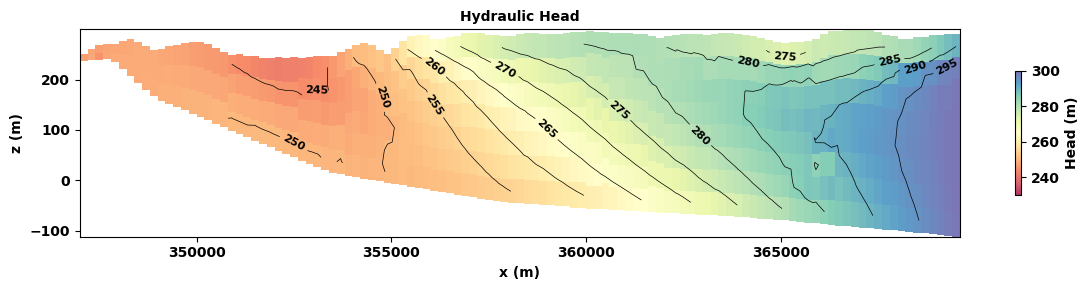

In [80]:
fm.plot_transect(mesh, spatial, geomodel, 
                title = f'Hydraulic Head',
                array = 'head', 
                grid = False, 
                contours = True,
                x0=mesh.xc[0], x1=mesh.xc[-1], 
                y0=mesh.yc[0], y1=mesh.yc[-1],
                levels = np.arange(220, 300, 5), # Only need to include if plotting contours
                vectors = False,
                normalize = True,
                kstep = 50, hstep = 20, # IF VECTORS = TRUE, need this line! spacing vertical, horizontal
                figsize = (12, 3),
                label = 'Head (m)',
                vmin = 230, vmax = 300 # can change scale of color
                )  

#### Plot water table

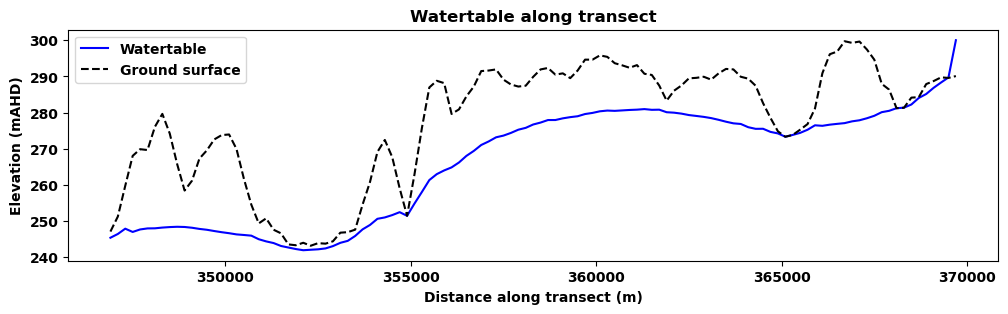

In [81]:
fm.watertable = []
for lay in range(1): # Just top layer for now
    for icpl in range(mesh.ncpl):
        cell_disv = icpl + lay*mesh.ncpl
        cell_disu = geomodel.cellid_disu.flatten()[cell_disv]
        
        if cell_disu != -1: # if cell is not pinched out...
            fm.watertable.append(fm.head[0, cell_disu])

fig = plt.figure(figsize=(12,3))
ax = fig.add_subplot(1,1,1)
ax.plot(mesh.xc, fm.watertable, 'b-', label = 'Watertable')
ax.plot(mesh.xc, geomodel.top, 'k--', label = 'Ground surface')
ax.set_xlabel('Distance along transect (m)')
ax.set_ylabel('Elevation (mAHD)')
ax.set_title('Watertable along transect')
ax.legend()

346900.63694429275 369700.6369442928 6710502.013288996 6720415.056767258 -300 400


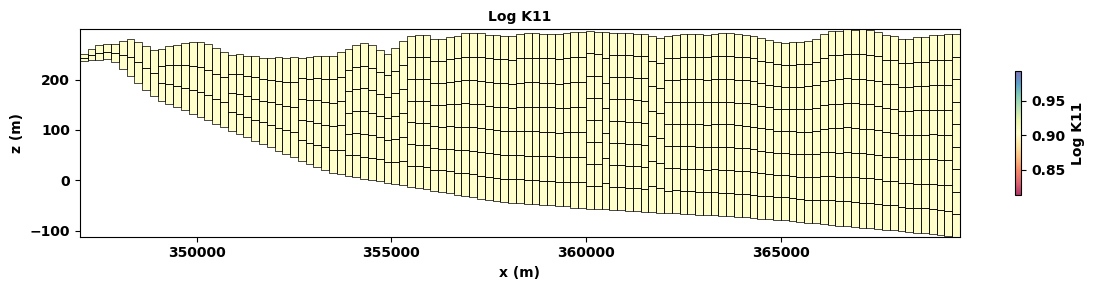

In [82]:
fm.plot_transect(mesh, spatial, geomodel, 
                title = 'Log K11',
                array = 'logk11', 
                grid = True, 
                contours = False,
                x0=mesh.xc[0], x1=mesh.xc[-1], 
                y0=mesh.yc[0], y1=mesh.yc[-1],
                levels = np.arange(30, 70, 50), # Only need to include if plotting contours
                vectors = False,
                normalize = True,
                kstep = 50, hstep = 20, # IF VECTORS = TRUE, need this line! spacing vertical, horizontal
                figsize = (12, 3),
                label = 'Log K11',
                #vmin = 0, vmax = 100 # can change scale of color
                )  

347000 370000 6710000 6720000 -300 400


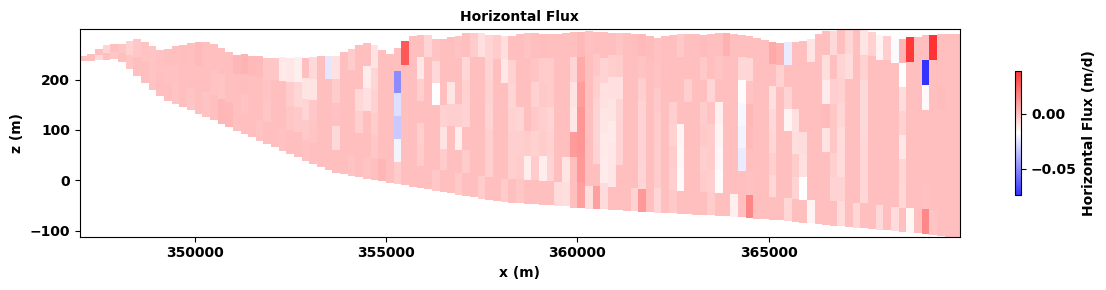

In [83]:
fm.plot_transect(mesh, spatial, geomodel, 'qx', 
                    grid = False,
                    #z0 = -600, z1 = 100,
                    #vmin = -2e-8, vmax = 4e-12,
                    title = f"Horizontal Flux",
                    figsize = (12,3),
                    label = "Horizontal Flux (m/d)",
                    cmap = 'bwr'
                    )



In [84]:
np.min(fm.qx), np.max(fm.qx)

(np.float64(-0.07410823212349013), np.float64(0.038860004353675544))

347000 370000 6710000 6720000 -300 400


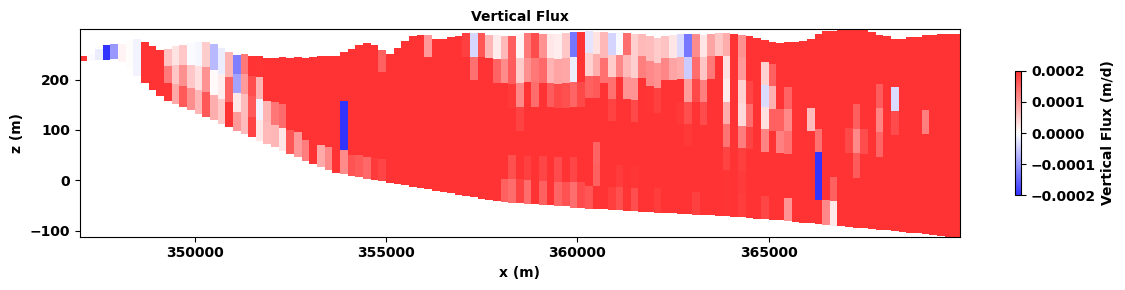

In [85]:
fm.plot_transect(mesh, spatial, geomodel, 'qz', 
                    grid = False,
                    #z0 = -600, z1 = 100,
                    vmin = -0.0002, vmax = 0.0002,
                    title = f"Vertical Flux",
                    figsize = (12,3),
                    label = "Vertical Flux (m/d)",
                    cmap = 'bwr'
                    )

In [86]:
np.min(fm.qz), np.max(fm.qz)

(np.float64(-0.0014058386945481542), np.float64(0.004486469006041954))